# Neural Network Taxi Demand Prediction -- Pooled Model (Census Tract)

Census-tract extension of `03.04`/`03.05` (community area) -- same pooled architecture, at finer spatial resolution.

- Same pooled-NN approach, validation strategy, and skill-score methodology as `03.04`.
- Rebuilds the community-area panel (Sections 1-3) as shared foundation for Section 5's tract
  panel; tract identity is a dedicated one-hot dummy per tract (5.1). The community-area
  profile baseline itself (5.2.1) is computed after the tract-level extrapolation (5.2), not
  before Section 5, since it exists to support the tract-level baseline in 5.4.
- **Scope**: 179 tracts across 11 community areas with enough tract-precision data; `03.05` is
  the fallback everywhere else.
- **Course constraint**: no lagged/autoregressive demand features.

**Notebook structure**:
1. Community-area foundation (1-3)
2. Census tract level (5): scope (5.0), tract dummies (5.1), panel & extrapolation (5.2),
   community-area baseline (5.2.1), features & split (5.3), tract baseline (5.4), Shallow NN
   (5.5), Deep NN (5.6), results (5.7)
3. Export, shortfalls & outlook (6-8)

## Validation Strategy

Same as `03.04`: chronological holdout, zero-filled grid, profile baseline, skill score.
Corrections carried over from `03.04`:

- **Day-blocked early-stopping split, not row-random**: tracts share weather/time features at a
  given timestamp, so `train_tract` is split by whole **days** into `nn_fit_t`/`nn_es_t`.
- **Stopping and selection on the same, count-space metric**: demand-weighted RMSE on `nn_es_t`,
  not log-scale MSE.
- **Final models refit on all of `train_tract`** after the stopping epoch is found.
- **No repeated architecture search at tract level (5.6)**: the tuned Deep NN config from `03.04`
  is reused directly.
- **Uncertainty**: a day-block bootstrap puts a 95% CI on Shallow vs. Deep NN's demand-weighted
  skill (5.7.0b).

In [13]:
import pathlib
import json
import time

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import contextily as ctx
import pyarrow.dataset as ds
import holidays

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TAXI_DATA_PATH       = "../../data/chicago_taxi_2024_2026_clean.parquet"
WEATHER_DATA_PATH    = "../../data/chicago_weather_2024_2026_hourly.csv"
COMMUNITY_AREAS_PATH = "../../data/community_areas_chicago.geojson"

# Data range covered by the cleaned parquet (June 2026+ excluded: portal reporting lag)
DATA_START    = pd.Timestamp("2024-01-01")
DATA_END_EXCL = pd.Timestamp("2026-06-01")

# Chronological split: train 2024-2025 (two full years), test Jan-May 2026
TRAIN_END = pd.Timestamp("2026-01-01")

# Evaluation week for baseline/model comparison charts (same week 03.05 uses)
EVAL_WEEK_START = pd.Timestamp("2026-03-02")
EVAL_WEEK_END   = EVAL_WEEK_START + pd.Timedelta(days=7)

FREQ = "4h"  # community-area resolution at 4h windows only
WEATHER_COLS = ["temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover"]

ALL_AREAS = np.arange(1, 78)  # official community areas 1..77 -- ALL of them, no threshold

# expm1(709) overflows float64; clip the log-scale prediction first so an unstable model gets a
# very bad but finite score instead of crashing.
LOG_PRED_CAP = 20

# Chart colors (validated palette: sequential blue, diverging blue<->red)
SEQUENTIAL_BLUE = "#256abf"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging_blue_red", ["#e34948", "#f0efec", "#2a78d6"])
CATEGORICAL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
# Reproducibility on GPU: without these, cuDNN picks nondeterministic kernels and single-run
# comparisons (e.g. the bootstrap-vs-point-estimate story in 5.7.0b) can shift between runs.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

NN_MAX_EPOCHS = 200
NN_PATIENCE   = 8
N_BOOT        = 500  # day-block bootstrap resamples for the skill confidence intervals

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

print(f"train: {DATA_START.date()} to {TRAIN_END.date()}  "
      f"test: {TRAIN_END.date()} to {DATA_END_EXCL.date()}")

Using device: cpu
train: 2024-01-01 to 2026-01-01  test: 2026-01-01 to 2026-06-01


## 1. Data Loading

Combined 2024-2026 taxi parquet + hourly weather. Only pickup community area and trip timestamp
needed.

In [14]:
taxi = pd.read_parquet(TAXI_DATA_PATH, columns=["trip_start_timestamp", "pickup_community_area"])
n_raw = len(taxi)
taxi = taxi[taxi["pickup_community_area"].notna()].copy()
taxi["pickup_community_area"] = taxi["pickup_community_area"].astype(int)
print(f"Trips with pickup CA: {len(taxi):,} of {n_raw:,} ({len(taxi)/n_raw*100:.1f}%)")

weather = pd.read_csv(WEATHER_DATA_PATH)
weather["datetime"] = pd.to_datetime(weather["datetime"])
weather = weather[["datetime"] + WEATHER_COLS]
print(f"Weather rows: {len(weather):,}")

Trips with pickup CA: 14,201,846 of 14,465,650 (98.2%)
Weather rows: 21,168


## 2. Building the Community-Area Panel (Foundation)

Zero-filled area x window grid, all 77 areas -- foundation for Section 5's tract panel (shared
weather aggregation, holiday calendar, time grid). Time features include a second harmonic for
hour and day-of-week.

In [15]:
# US federal holidays (incl. observed dates), computed for every year the data covers --
# avoids maintaining a hand-picked date list that silently goes stale outside 2024-2026.
US_HOLIDAYS = pd.DatetimeIndex(sorted(
    holidays.US(years=range(DATA_START.year, DATA_END_EXCL.year + 1))
))

window = taxi["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts = taxi.groupby(["pickup_community_area", window]).size().rename("count")

all_windows = pd.date_range(DATA_START, DATA_END_EXCL, freq=FREQ, inclusive="left")
grid = pd.MultiIndex.from_product([ALL_AREAS, all_windows], names=["community_area", "timestamp"])
panel = counts.reindex(grid, fill_value=0).reset_index()

# Weather -> one city-wide value per window. Reindex onto the full window grid and interpolate
# any gaps (weather is temporally smooth), so no window silently gets NaN features that would
# poison the scaler / gradients downstream -- reused as-is by the tract panel in Section 5.2.
w = weather.copy()
w["timestamp"] = w["datetime"].dt.floor(FREQ)
w_agg = (w.groupby("timestamp")[WEATHER_COLS].mean()
           .reindex(all_windows)
           .interpolate(limit_direction="both"))
n_weather_gaps = int(w_agg.isna().sum().sum())
if n_weather_gaps:
    print(f"WARNING: {n_weather_gaps} weather cells still NaN after interpolation")
w_agg = w_agg.rename_axis("timestamp").reset_index()
panel = panel.merge(w_agg, on="timestamp", how="left")
assert panel[WEATHER_COLS].isna().sum().sum() == 0, "weather NaNs remain after merge"

panel["hour"]        = panel["timestamp"].dt.hour
panel["day_of_week"] = panel["timestamp"].dt.dayofweek
month                = panel["timestamp"].dt.month
panel["month"]       = month

panel["hour_sin"]         = np.sin(2 * np.pi * panel["hour"] / 24)
panel["hour_cos"]         = np.cos(2 * np.pi * panel["hour"] / 24)
panel["hour_sin2"]        = np.sin(4 * np.pi * panel["hour"] / 24)
panel["hour_cos2"]        = np.cos(4 * np.pi * panel["hour"] / 24)
panel["day_of_week_sin"]  = np.sin(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos"]  = np.cos(2 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_sin2"] = np.sin(4 * np.pi * panel["day_of_week"] / 7)
panel["day_of_week_cos2"] = np.cos(4 * np.pi * panel["day_of_week"] / 7)
panel["month_sin"]        = np.sin(2 * np.pi * month / 12)
panel["month_cos"]        = np.cos(2 * np.pi * month / 12)
panel["is_weekend"]       = (panel["day_of_week"] >= 5).astype(int)
panel["is_holiday"]       = panel["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

dummies = pd.get_dummies(panel["community_area"], prefix="area", drop_first=True).astype(float)
DUMMY_COLS = list(dummies.columns)
panel = pd.concat([panel, dummies], axis=1)

panel = panel.sort_values(["community_area", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel):,} rows ({panel['community_area'].nunique()} areas x "
      f"{panel['timestamp'].nunique():,} windows), {len(DUMMY_COLS)} area dummies, "
      f"zero-demand windows: {(panel['count']==0).mean()*100:.1f}%")

4h: 407,484 rows (77 areas x 5,292 windows), 76 area dummies, zero-demand windows: 18.9%


## 3. Feature Set & Shared Helpers

17 exogenous time/weather features + 76 community-area dummies (community-area level only).
Evaluation helpers (`metrics`, `weighted_rmse`, `predict_counts`, `per_area_results`,
`skill_vs_baseline`, ...) are reused for tract-level scoring via their `group_col`/`baseline_df`
parameters.

In [16]:
FEATURE_COLS = [
    "temperature_2m", "precipitation", "snowfall", "wind_speed_10m", "cloud_cover",
    "hour_sin", "hour_cos", "hour_sin2", "hour_cos2",
    "day_of_week_sin", "day_of_week_cos", "day_of_week_sin2", "day_of_week_cos2",
    "month_sin", "month_cos", "is_weekend", "is_holiday",
]
ALL_COLS = FEATURE_COLS + DUMMY_COLS

train = panel[panel["timestamp"] < TRAIN_END].reset_index(drop=True)
test  = panel[panel["timestamp"] >= TRAIN_END].reset_index(drop=True)
y_true = test["count"].to_numpy(dtype=float)
print(f"train={len(train):,} rows   test={len(test):,} rows")


def metrics(y_true, y_pred):
    return {
        "r2":   round(r2_score(y_true, y_pred), 4),
        "mae":  round(mean_absolute_error(y_true, y_pred), 2),
        "rmse": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 2),
    }


def predict_counts(model, X):
    """Back-transform log-scale predictions to counts, clipped at 0 (and capped pre-expm1
    so an unstable model's prediction can't overflow to inf)."""
    y_log = np.clip(model.predict(X), -LOG_PRED_CAP, LOG_PRED_CAP)
    return np.clip(np.expm1(y_log), 0, None)


def per_area_results(test_df, y_pred, group_col="community_area"):
    """One row per spatial unit: MAE/R2/RMSE of the pooled model's predictions for that unit.
    `group_col` generalizes this across resolutions (community area now, census tract in
    Section 5) so the same evaluation code is reused rather than duplicated per resolution."""
    tmp = pd.DataFrame({
        group_col: test_df[group_col].to_numpy(),
        "y_true": test_df["count"].to_numpy(dtype=float),
        "y_pred": y_pred,
    })
    rows = [
        {group_col: g, **metrics(g_df["y_true"], g_df["y_pred"])}
        for g, g_df in tmp.groupby(group_col)
    ]
    return pd.DataFrame(rows)


def skill_vs_baseline(results_df, baseline_df=None, group_col="community_area"):
    """Per-unit skill score: 1 - MAE_model / MAE_baseline. `baseline_df` defaults to the
    community-area `baseline_results` for backward compatibility; pass the tract-level
    baseline explicitly at tract resolution (Section 5)."""
    if baseline_df is None:
        baseline_df = baseline_results
    base = baseline_df[[group_col, "mae"]].rename(columns={"mae": "mae_base"})
    merged = results_df.merge(base, on=group_col)
    return (1 - merged["mae"] / merged["mae_base"]).rename("skill")


AREA_MEDIAN_DEMAND = panel.groupby("community_area")["count"].median().rename("median_demand")


def weighted_skill_vs_baseline(results_df, baseline_df=None, median_demand=None, group_col="community_area"):
    """Demand-weighted mean skill -- the headline metric. `baseline_df`/`median_demand` default
    to the community-area globals; pass the tract-level equivalents explicitly at tract
    resolution (Section 5). Zero-weight units (e.g. a tract with no recorded trips) are dropped
    before averaging: their weight is 0 either way, but if their baseline is a perfect (mae_base
    == 0) constant-zero predictor, 0 * inf would otherwise poison the whole weighted average with
    NaN."""
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    skill = skill_vs_baseline(results_df, baseline_df=baseline_df, group_col=group_col)
    weights = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    mask = weights > 0
    return float(np.average(skill.to_numpy()[mask], weights=weights[mask]))


def weighted_rmse(y_true, y_pred, weights):
    """Pooled RMSE with each row weighted by its unit's train-period mean demand -- the number
    comparable against 03.04/03.05."""
    return float(np.sqrt(np.average((np.asarray(y_true) - np.asarray(y_pred)) ** 2, weights=weights)))


def relative_mae(results_df, median_demand=None, group_col="community_area"):
    if median_demand is None:
        median_demand = AREA_MEDIAN_DEMAND
    demand = results_df[[group_col]].merge(
        median_demand, left_on=group_col, right_index=True
    )["median_demand"].to_numpy()
    return pd.Series(results_df["mae"].to_numpy() / (demand + 1), index=results_df.index, name="relative_mae")


def print_pooled_results(label, pooled_metrics, per_area_df, baseline_df=None, median_demand=None,
                          group_col="community_area", weighted_rmse_value=None):
    w_skill = weighted_skill_vs_baseline(
        per_area_df, baseline_df=baseline_df, median_demand=median_demand, group_col=group_col,
    )
    print(label)
    print(f"  Pooled       : R2={pooled_metrics['r2']:.3f}  MAE={pooled_metrics['mae']:.2f}  "
          f"RMSE={pooled_metrics['rmse']:.2f}  (sanity check only)")
    if weighted_rmse_value is not None:
        print(f"  Weighted RMSE: {weighted_rmse_value:.2f}  (headline)")
    print(f"  Skill        : demand-weighted (headline)={w_skill:+.3f}  "
          f"unweighted median={per_area_df['skill'].median():+.3f}  "
          f"median R2={per_area_df['r2'].median():.3f}  "
          f"(areas with negative skill: {(per_area_df['skill']<0).sum()} of {len(per_area_df)})")

train=337,722 rows   test=69,762 rows


## 5. Census Tract Level

- `pickup_census_tract` is **not usable as an ID**: only 44.6% populated, stored as `float32`
  (corrupts 11-digit GEOIDs on rounding). Its *presence* still matters: Chicago masks a trip's
  tract to its community area's centroid whenever too few trips occurred in the period (a
  privacy rule), so `pickup_census_tract.notna()` flags genuinely tract-precise rows -- drives
  both scope (5.0) and how counts are built (5.2).
- **Tract identity via one-hot dummies, not hand-built covariates**: an earlier version of this
  notebook gave the NN a community-area dummy plus 8 continuous covariates (POI count, tract
  area, distance to 6 GMM demand hot spots) as a tract-identity proxy. That scored *worse than
  the profile baseline* (demand-weighted skill: Shallow NN -0.42, Deep NN -0.30), because the
  baseline conditions on the exact `tract_id` while the NN only saw a coarse proxy for it. This
  notebook instead uses one dummy per in-scope tract (179 tracts -> 178 columns, drop-first),
  feasible here because a linear output layer handles a ~180-column one-hot block without
  difficulty -- see Section 7 for the trade-off this switch makes.

### 5.0 Tract-Precision Coverage & Modeling Scope

Community areas retaining fewer than `RETENTION_THRESHOLD = 0.05` of trips at tract precision
are excluded (natural gap between 4.85% and 7.17%) -- **11 of 77 community areas / 179 of 878
tracts** in scope; `03.05`'s community-area model is the fallback everywhere else.

### 5.1 Tract Identity: One-Hot Dummies

Each in-scope tract gets its own fixed-effect dummy (`pd.get_dummies(tract_id, drop_first=True)`),
built once the tract panel exists (5.2) -- the tract-level counterpart of `03.04`/`03.05`'s
community-area dummies. No GMM hot-spot distances or POI/tract-area covariates are computed here
anymore; a tract dummy already captures everything time-invariant about a tract exactly, rather
than as a lossy proxy.

In [17]:
CENSUS_TRACTS_PATH = "../../data/census_tracts_chicago.geojson"

# ---- 5.0: Tract-precision retention per community area (decides modeling scope) ----
retention_raw = pd.read_parquet(TAXI_DATA_PATH, columns=["pickup_census_tract", "pickup_community_area"])
retention_raw = retention_raw.dropna(subset=["pickup_community_area"]).copy()
retention_raw["pickup_community_area"] = retention_raw["pickup_community_area"].astype(int)
retention_raw["has_tract"] = retention_raw["pickup_census_tract"].notna()

AREA_RETENTION = retention_raw.groupby("pickup_community_area")["has_tract"].mean().rename("retention_frac")
del retention_raw

RETENTION_THRESHOLD = 0.05  # natural gap in the data: no area falls between 4.85% and 7.17%
INCLUDED_AREAS = np.sort(AREA_RETENTION[AREA_RETENTION >= RETENTION_THRESHOLD].index.to_numpy())
EXCLUDED_AREAS = np.sort(AREA_RETENTION[AREA_RETENTION < RETENTION_THRESHOLD].index.to_numpy())
AREA_SCALE_FACTOR = (1 / AREA_RETENTION).rename("scale_factor")  # inverse retention -> estimated total demand

print(f"{len(INCLUDED_AREAS)} of {len(AREA_RETENTION)} community areas retain >= "
      f"{RETENTION_THRESHOLD*100:.0f}% tract-precision trips -- in scope for tract-level modeling:")
print(f"  included: {INCLUDED_AREAS.tolist()}")
print(f"  excluded (use 03.05's community-area model instead): {EXCLUDED_AREAS.tolist()}")

# ---- Tract boundaries, restricted to included areas -- tract_id is now the model's entire
# spatial identity (5.1), so no POI/tract-area/hotspot covariates are computed here anymore. ----
tracts_gdf = gpd.read_file(CENSUS_TRACTS_PATH)[["census_t_1", "tract_comm", "geometry"]].copy()
tracts_gdf["tract_id"] = tracts_gdf["census_t_1"].astype("int64")
tracts_gdf["community_area"] = tracts_gdf["tract_comm"].astype(int)
tracts_gdf = tracts_gdf[tracts_gdf["community_area"].isin(INCLUDED_AREAS)].copy()
ALL_TRACTS = np.sort(tracts_gdf["tract_id"].to_numpy())

print(f"{len(tracts_gdf)} tracts in scope (of 878 total)")

# ---- Taxi trips -> tract, via spatial join on TRACT-PRECISION TRIPS ONLY ----
taxi_dataset = ds.dataset(TAXI_DATA_PATH, format="parquet")
taxi_filter = ds.field("pickup_census_tract").is_valid() & ds.field("pickup_community_area").isin(INCLUDED_AREAS)
taxi_t = taxi_dataset.to_table(
    columns=["trip_start_timestamp", "pickup_centroid_latitude", "pickup_centroid_longitude"],
    filter=taxi_filter,
).to_pandas()
n_raw_t = taxi_dataset.count_rows()
taxi_t = taxi_t.dropna(subset=["pickup_centroid_latitude", "pickup_centroid_longitude"]).copy()

taxi_gdf = gpd.GeoDataFrame(
    taxi_t, geometry=gpd.points_from_xy(taxi_t["pickup_centroid_longitude"], taxi_t["pickup_centroid_latitude"]), crs="EPSG:4326",
)
taxi_t = gpd.sjoin(taxi_gdf, tracts_gdf[["tract_id", "geometry"]], how="left", predicate="within")
taxi_t = pd.DataFrame(taxi_t.drop(columns="geometry")).dropna(subset=["tract_id"]).copy()
taxi_t["tract_id"] = taxi_t["tract_id"].astype("int64")

print(f"Tract-precision trips in included areas: {len(taxi_t):,} of {n_raw_t:,} total trips "
      f"({len(taxi_t)/n_raw_t*100:.1f}%), covering {taxi_t['tract_id'].nunique()} of "
      f"{len(ALL_TRACTS)} in-scope tracts.")

11 of 77 community areas retain >= 5% tract-precision trips -- in scope for tract-level modeling:
  included: [3, 6, 7, 8, 28, 32, 33, 41, 56, 59, 76]
  excluded (use 03.05's community-area model instead): [1, 2, 4, 5, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 34, 35, 36, 37, 38, 39, 40, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 57, 58, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 77]
179 tracts in scope (of 878 total)
Tract-precision trips in included areas: 6,423,800 of 14,465,650 total trips (44.4%), covering 125 of 179 in-scope tracts.


### 5.1.1 Map: Tracts In Scope

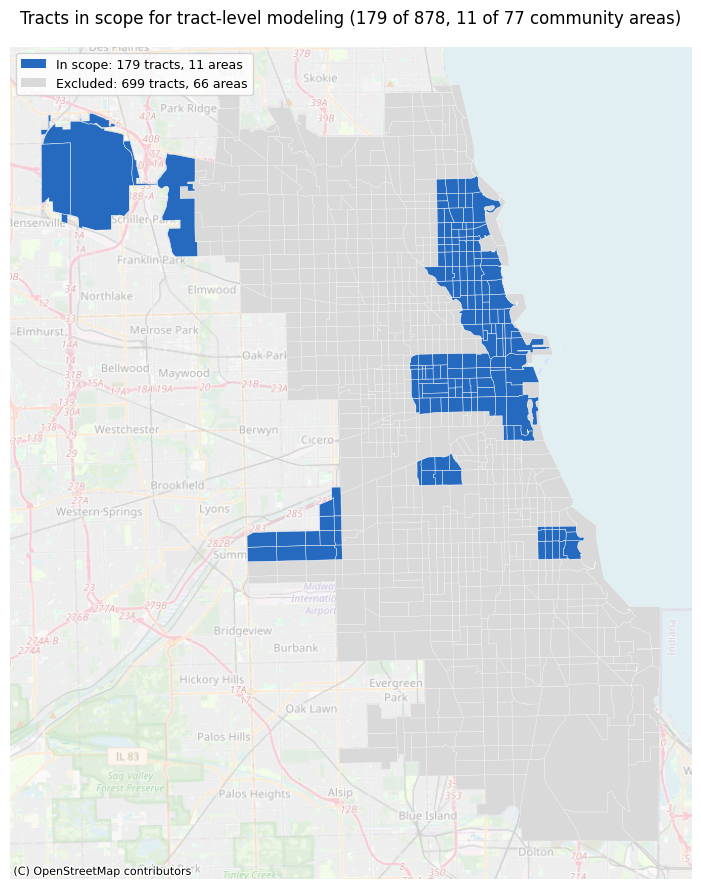

In [18]:
all_tracts_gdf = gpd.read_file(CENSUS_TRACTS_PATH)[["census_t_1", "tract_comm", "geometry"]].copy()
all_tracts_gdf["tract_id"] = all_tracts_gdf["census_t_1"].astype("int64")
all_tracts_gdf["community_area"] = all_tracts_gdf["tract_comm"].astype(int)
all_tracts_gdf["in_scope"] = all_tracts_gdf["community_area"].isin(INCLUDED_AREAS)
all_tracts_gdf = all_tracts_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
all_tracts_gdf[~all_tracts_gdf["in_scope"]].plot(ax=ax, color="#d9d9d9", edgecolor="white", linewidth=0.2)
all_tracts_gdf[all_tracts_gdf["in_scope"]].plot(ax=ax, color=SEQUENTIAL_BLUE, edgecolor="white", linewidth=0.3)
ctx.add_basemap(ax, crs=all_tracts_gdf.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title(f"Tracts in scope for tract-level modeling ({len(ALL_TRACTS)} of 878, "
             f"{len(INCLUDED_AREAS)} of 77 community areas)")
legend_handles = [
    Patch(facecolor=SEQUENTIAL_BLUE, label=f"In scope: {len(ALL_TRACTS)} tracts, {len(INCLUDED_AREAS)} areas"),
    Patch(facecolor="#d9d9d9", label=f"Excluded: {878 - len(ALL_TRACTS)} tracts, {77 - len(INCLUDED_AREAS)} areas"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9)
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.2 Building the Tract Panel

Zero-filled grid restricted to the 179 in-scope tracts; counts from tract-precision trips only,
scaled up per area by the inverse retention fraction (5.0) to estimate total demand. Spatial
identity is the one-hot `tract_id` dummy (5.1), built at the end of this step.

In [19]:
window_t = taxi_t["trip_start_timestamp"].dt.floor(FREQ).rename("timestamp")
counts_t = taxi_t.groupby(["tract_id", window_t]).size().rename("count")

grid_t = pd.MultiIndex.from_product([ALL_TRACTS, all_windows], names=["tract_id", "timestamp"])
panel_t = counts_t.reindex(grid_t, fill_value=0).reset_index()
panel_t = panel_t.merge(w_agg, on="timestamp", how="left")
assert panel_t[WEATHER_COLS].isna().sum().sum() == 0, "weather NaNs remain after merge (tract panel)"

panel_t["hour"]        = panel_t["timestamp"].dt.hour
panel_t["day_of_week"] = panel_t["timestamp"].dt.dayofweek
month_t                = panel_t["timestamp"].dt.month
panel_t["month"]       = month_t

panel_t["hour_sin"]         = np.sin(2 * np.pi * panel_t["hour"] / 24)
panel_t["hour_cos"]         = np.cos(2 * np.pi * panel_t["hour"] / 24)
panel_t["hour_sin2"]        = np.sin(4 * np.pi * panel_t["hour"] / 24)
panel_t["hour_cos2"]        = np.cos(4 * np.pi * panel_t["hour"] / 24)
panel_t["day_of_week_sin"]  = np.sin(2 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_cos"]  = np.cos(2 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_sin2"] = np.sin(4 * np.pi * panel_t["day_of_week"] / 7)
panel_t["day_of_week_cos2"] = np.cos(4 * np.pi * panel_t["day_of_week"] / 7)
panel_t["month_sin"]        = np.sin(2 * np.pi * month_t / 12)
panel_t["month_cos"]        = np.cos(2 * np.pi * month_t / 12)
panel_t["is_weekend"]       = (panel_t["day_of_week"] >= 5).astype(int)
panel_t["is_holiday"]       = panel_t["timestamp"].dt.date.isin(US_HOLIDAYS.date).astype(int)

panel_t = panel_t.merge(tracts_gdf[["tract_id", "community_area"]], on="tract_id", how="left")

# Scale observed tract-precision counts up to estimate total demand (Section 5.0).
panel_t["count_observed"] = panel_t["count"]
panel_t["count"] = panel_t["count_observed"] * panel_t["community_area"].map(AREA_SCALE_FACTOR)

# Tract spatial identity (5.1): one dummy per in-scope tract, the tract-level counterpart of
# 03.04/03.05's community-area dummies -- replaces the community-area dummy + hand-built spatial
# covariates an earlier version of this notebook used.
tract_dummies = pd.get_dummies(pd.Categorical(panel_t["tract_id"], categories=ALL_TRACTS), prefix="tract", drop_first=True).astype(float)
TRACT_DUMMY_COLS = list(tract_dummies.columns)
panel_t = pd.concat([panel_t, tract_dummies], axis=1)

panel_t = panel_t.sort_values(["tract_id", "timestamp"]).reset_index(drop=True)
print(f"{FREQ}: {len(panel_t):,} rows ({panel_t['tract_id'].nunique()} tracts x "
      f"{panel_t['timestamp'].nunique():,} windows), {len(TRACT_DUMMY_COLS)} tract dummies, "
      f"zero-demand windows: {(panel_t['count']==0).mean()*100:.1f}%")

4h: 947,268 rows (179 tracts x 5,292 windows), 178 tract dummies, zero-demand windows: 85.5%


### 5.2.1 Profile Baseline (Community Area, Foundation)

Same helper reused for the tract-level baseline in 5.4 (`group_col="tract_id"`); placed here, right after the tract panel and its extrapolation (5.2), instead of before Section 5.

Profile baseline, all 77 areas (1s)
  Pooled  : R2=0.933  MAE=9.53  RMSE=37.31
  Per area: median R2=0.208  median MAE=2.13  median RMSE=2.80  (areas with R2<0: 21 of 77)


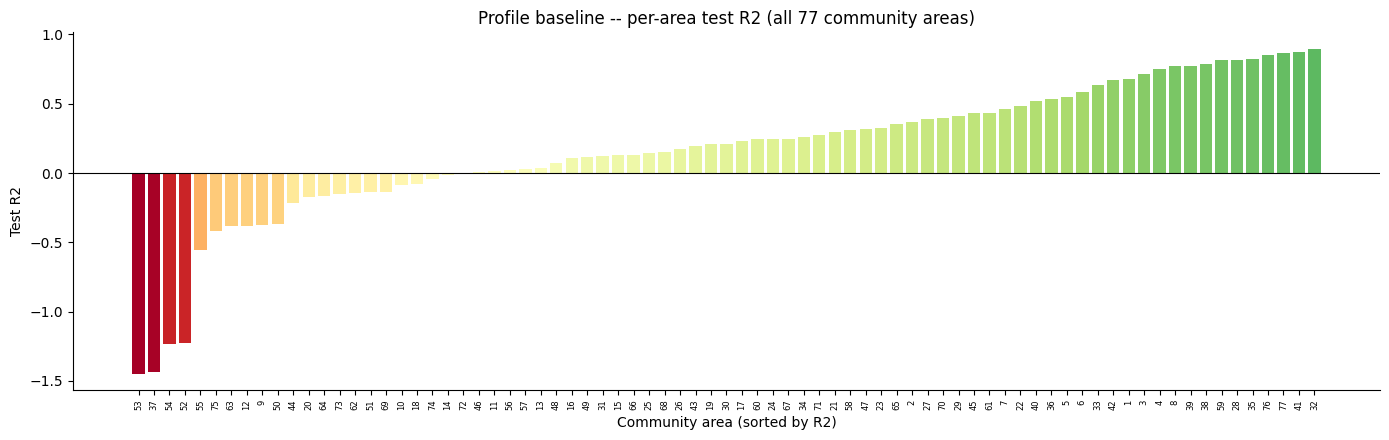

In [20]:
def profile_baseline(panel, groups, group_col="community_area"):
    results = []
    y_true_all, y_pred_all = [], []
    for g in groups:
        df_g = panel[panel[group_col] == g]
        tr = df_g[df_g["timestamp"] < TRAIN_END]
        te = df_g[df_g["timestamp"] >= TRAIN_END]
        profile = tr.groupby(["hour", "day_of_week", "month"])["count"].mean()
        fallback = tr["count"].mean()
        keys = pd.MultiIndex.from_arrays([te["hour"], te["day_of_week"], te["month"]])
        y_pred = profile.reindex(keys).fillna(fallback).to_numpy()
        y_true_ = te["count"].to_numpy(dtype=float)
        results.append({
            group_col: g,
            "median_demand": float(df_g["count"].median()),
            **metrics(y_true_, y_pred),
        })
        y_true_all.append(y_true_)
        y_pred_all.append(y_pred)
    per_group_df = pd.DataFrame(results)
    y_true_concat, y_pred_concat = np.concatenate(y_true_all), np.concatenate(y_pred_all)
    pooled = metrics(y_true_concat, y_pred_concat)
    return per_group_df, pooled, y_true_concat, y_pred_concat


t0 = time.time()
baseline_results, pm_baseline, baseline_y_true, baseline_y_pred = profile_baseline(panel, ALL_AREAS)
baseline_results["community_area"] = baseline_results["community_area"].astype(int)

print(f"Profile baseline, all 77 areas ({time.time()-t0:.0f}s)")
print(f"  Pooled  : R2={pm_baseline['r2']:.3f}  MAE={pm_baseline['mae']:.2f}  RMSE={pm_baseline['rmse']:.2f}")
print(f"  Per area: median R2={baseline_results['r2'].median():.3f}  "
      f"median MAE={baseline_results['mae'].median():.2f}  "
      f"median RMSE={baseline_results['rmse'].median():.2f}  "
      f"(areas with R2<0: {(baseline_results['r2']<0).sum()} of {len(baseline_results)})")

plot_df = baseline_results.sort_values("r2").reset_index(drop=True)
vlim = max(0.5, plot_df["r2"].abs().max())
colors = plt.cm.RdYlGn((plot_df["r2"] + vlim) / (2 * vlim))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df)), plot_df["r2"], color=colors, width=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(plot_df)))
ax.set_xticklabels(plot_df["community_area"], rotation=90, fontsize=6)
ax.set_xlabel("Community area (sorted by R2)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-area test R2 (all 77 community areas)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.3 Feature Set & Train/Test Split (Tract Level)

Same 17 time/weather features as `03.04`, plus 178 tract dummies (179 in-scope tracts,
drop-first) in place of community-area dummies -- the tract-level counterpart of `03.04`/`03.05`'s
one-hot encoding.

In [21]:
FEATURE_COLS_TRACT = FEATURE_COLS
ALL_COLS_TRACT = FEATURE_COLS_TRACT + TRACT_DUMMY_COLS

train_tract = panel_t[panel_t["timestamp"] < TRAIN_END].reset_index(drop=True)
test_tract  = panel_t[panel_t["timestamp"] >= TRAIN_END].reset_index(drop=True)
y_true_tract = test_tract["count"].to_numpy(dtype=float)
print(f"train={len(train_tract):,} rows   test={len(test_tract):,} rows  "
      f"(~{len(train_tract)/len(train):.1f}x the community-area training set)")

train=785,094 rows   test=162,174 rows  (~2.3x the community-area training set)


### 5.4 Profile Baseline (Tract Level)

Same construction as Section 5.2.1, `group_col="tract_id"`. Expect a different aggregate shape: 179
units spread the same (scaled-up) demand thinner than 77 community areas do, so more units sit
in the near-zero regime.

Profile baseline, 179 in-scope tracts (4s)
  Pooled   : R2=0.896  MAE=5.22  RMSE=21.64
  Per tract: median R2=0.195  median MAE=0.13  median RMSE=1.13  (tracts with R2<0: 56 of 179)


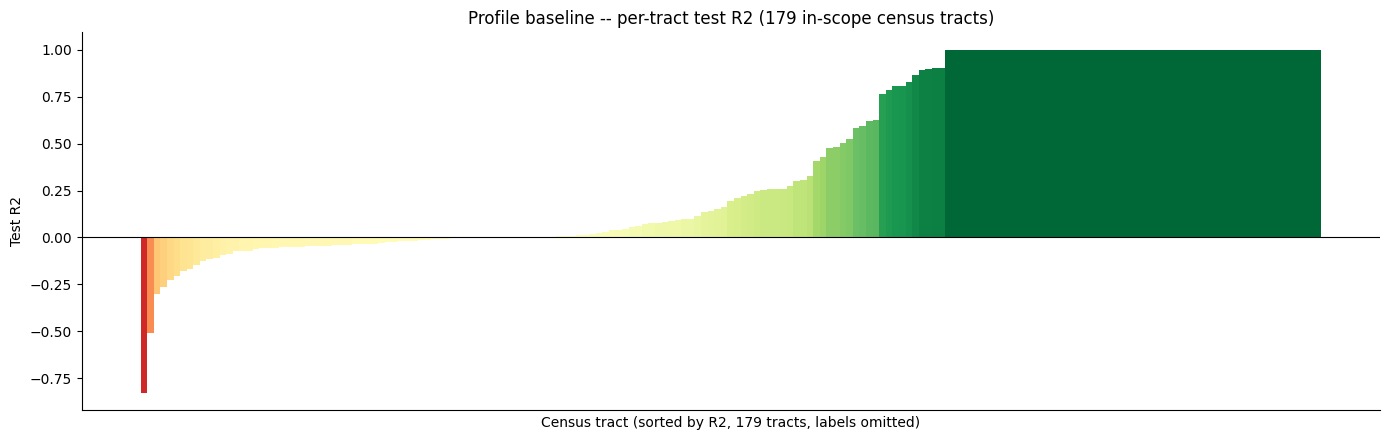

In [22]:
t0 = time.time()
baseline_results_tract, pm_baseline_tract, _, baseline_y_pred_tract = profile_baseline(
    panel_t, ALL_TRACTS, group_col="tract_id"
)

print(f"Profile baseline, {len(ALL_TRACTS)} in-scope tracts ({time.time()-t0:.0f}s)")
print(f"  Pooled   : R2={pm_baseline_tract['r2']:.3f}  MAE={pm_baseline_tract['mae']:.2f}  RMSE={pm_baseline_tract['rmse']:.2f}")
print(f"  Per tract: median R2={baseline_results_tract['r2'].median():.3f}  "
      f"median MAE={baseline_results_tract['mae'].median():.2f}  "
      f"median RMSE={baseline_results_tract['rmse'].median():.2f}  "
      f"(tracts with R2<0: {(baseline_results_tract['r2']<0).sum()} of {len(baseline_results_tract)})")

plot_df_t = baseline_results_tract.sort_values("r2").reset_index(drop=True)
vlim_t = max(0.5, plot_df_t["r2"].abs().max())
colors_t = plt.cm.RdYlGn((plot_df_t["r2"] + vlim_t) / (2 * vlim_t))

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(plot_df_t)), plot_df_t["r2"], color=colors_t, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([])
ax.set_xlabel(f"Census tract (sorted by R2, {len(plot_df_t)} tracts, labels omitted)")
ax.set_ylabel("Test R2")
ax.set_title("Profile baseline -- per-tract test R2 (179 in-scope census tracts)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.4.1 Baseline Performance -- Top Tracts

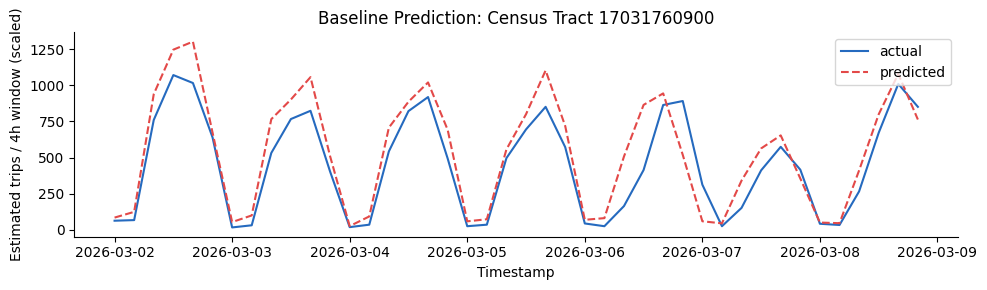

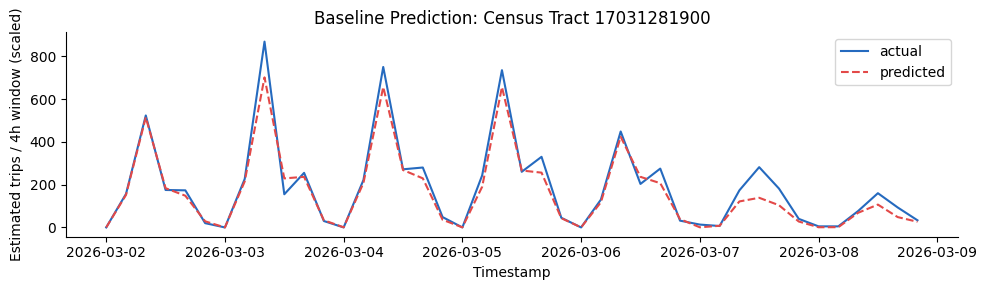

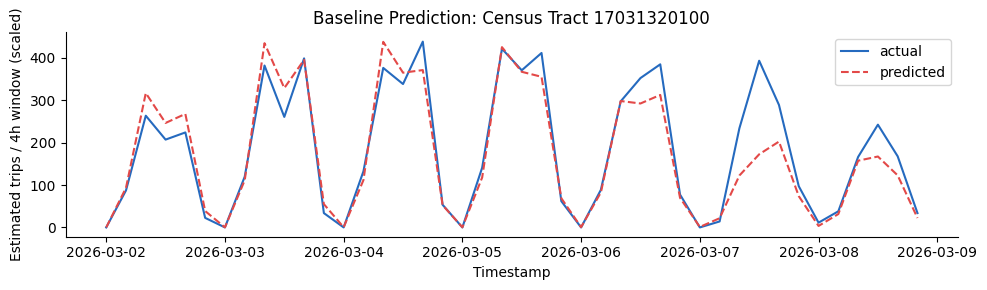

In [23]:
eval_mask_t = (test_tract["timestamp"] >= EVAL_WEEK_START) & (test_tract["timestamp"] < EVAL_WEEK_END)
test_plot_t = test_tract[eval_mask_t].reset_index(drop=True)
test_plot_pred_base_t = baseline_y_pred_tract[eval_mask_t.to_numpy()]

top_3_tracts = test_plot_t.groupby("tract_id")["count"].median().sort_values(ascending=False).head(3).index

for tract in top_3_tracts:
    mask = (test_plot_t["tract_id"] == tract).to_numpy()
    area_val = test_plot_t[mask]
    area_pred = test_plot_pred_base_t[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], area_pred, label="predicted", color="#e34948", linestyle="--")
    ax.set_title(f"Baseline Prediction: Census Tract {tract}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Estimated trips / 4h window (scaled)")
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

### 5.5 Shallow Neural Network -- Tract Level, Full Data

Pooled Shallow NN (one hidden layer, `hidden_dim=64`) on the full tract training set, no
subsampling. `train_tract` is split by whole **days** ~80/20 into `nn_fit_t`/`nn_es_t`. Early
stopping and the final metric both use demand-weighted RMSE on `nn_es_t` in count space; the
reported model is then **refit from scratch on all of `train_tract`** for the selected epoch
count. The `nn_fit_t`-only model is kept separately for permutation importance (5.5.1), where
`nn_es_t` must stay out-of-sample.

In [24]:
# Day-blocked early-stopping split (see Validation Strategy). At any given timestamp, tracts
# share the same weather/time features and differ only by their (static) tract dummy, so a
# row-random split can still place near-identical rows on both sides. Splitting whole DAYS
# keeps every window on one side.
train_days_t = np.sort(train_tract["timestamp"].dt.normalize().unique())
rng_split_t = np.random.default_rng(SEED)
n_es_days_t = int(round(0.2 * len(train_days_t)))
es_days_t = {pd.Timestamp(d) for d in rng_split_t.choice(train_days_t, size=n_es_days_t, replace=False)}
es_mask_t = train_tract["timestamp"].dt.normalize().isin(es_days_t)

nn_fit_t = train_tract[~es_mask_t].reset_index(drop=True)
nn_es_t  = train_tract[es_mask_t].reset_index(drop=True)
print(f"nn_fit_t: {len(nn_fit_t):,} rows ({len(train_days_t) - n_es_days_t} train days)")
print(f"nn_es_t:  {len(nn_es_t):,} rows ({n_es_days_t} held-out days -- no timestamp shared with nn_fit_t)")

# Train-period mean/median demand per tract -- same convention as 03.04/03.05, so weighted_rmse
# is directly comparable across resolutions and against the SVM notebooks. Defined once here so
# both the ES stopping criterion and the final reported metrics use the same weighting.
TRACT_MEDIAN_DEMAND = panel_t.groupby("tract_id")["count"].median().rename("median_demand")
TRACT_UNIT_WEIGHT = train_tract.groupby("tract_id")["count"].mean()
TEST_TRACT_UNIT_WEIGHTS = test_tract["tract_id"].map(TRACT_UNIT_WEIGHT).fillna(TRACT_UNIT_WEIGHT.mean()).to_numpy()

# Needed by fit_with_early_stopping's stopping criterion -- same weighting the headline weighted
# RMSE uses, just restricted to the (day-blocked) ES slice.
es_unit_w_t = nn_es_t["tract_id"].map(TRACT_UNIT_WEIGHT).fillna(TRACT_UNIT_WEIGHT.mean()).to_numpy()
es_true_t   = nn_es_t["count"].to_numpy(dtype=float)


def make_xy(df, cols, preprocess_obj, fit=False):
    Xs = (preprocess_obj.fit_transform(df[cols]) if fit else preprocess_obj.transform(df[cols])).astype(np.float32)
    y = np.log1p(df["count"].to_numpy(dtype=np.float32))
    return torch.from_numpy(Xs), torch.from_numpy(y)


class TorchRegressor:
    def __init__(self, model, preprocess_obj):
        self.model, self.preprocess_obj = model, preprocess_obj

    def predict(self, X):
        Xs = self.preprocess_obj.transform(X).astype(np.float32)
        self.model.eval()
        with torch.no_grad():
            return self.model(torch.from_numpy(Xs).to(device)).cpu().numpy()


class ShallowNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x))).squeeze(-1)


class DeepNet(nn.Module):
    def __init__(self, input_dim, hidden_dim1=128, hidden_dim2=64, dropout=0.2):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)
        self.fc3 = nn.Linear(hidden_dim2, 1)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.fc1(x)))
        x = self.dropout2(self.relu2(self.fc2(x)))
        return self.fc3(x).squeeze(-1)


class DeepNet5(nn.Module):
    """Five hidden layers + dropout after each -- supports a deep5 winner reused from 03.04."""
    def __init__(self, input_dim, hidden_dims=(512, 256, 128, 64, 32), dropout=0.2):
        super().__init__()
        dims = [input_dim] + list(hidden_dims)
        self.layers = nn.ModuleList([nn.Linear(dims[i], dims[i + 1]) for i in range(len(dims) - 1)])
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(hidden_dims[-1], 1)

    def forward(self, x):
        for layer in self.layers:
            x = self.drop(self.relu(layer(x)))
        return self.out(x).squeeze(-1)


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(xb)
    return running / len(loader.dataset)


def eval_loss(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        return criterion(model(X.to(device)), y.to(device)).item()


def fit_with_early_stopping(model_ctor, X_fit_t, y_fit_t, X_es_t, y_es_t, lr, weight_decay, batch_size,
                             nn_es_df, preprocess_obj, unit_weights, es_true_counts,
                             max_epochs=NN_MAX_EPOCHS, patience=NN_PATIENCE, label=""):
    """Same corrected procedure as 03.04: stop on count-space demand-weighted RMSE on the
    (day-blocked) ES slice, not log-space MSE. Used to FIND the stopping epoch; the reported
    model is refit on full train via fit_fixed_epochs."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()  # still the training loss; just not the stopping signal
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_fit_t, y_fit_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))

    best_loss, best_epoch, best_state, no_improve = float("inf"), 0, None, 0
    epoch = 0
    for epoch in range(1, max_epochs + 1):
        train_epoch(model, loader, criterion, optimizer)
        es_pred = predict_counts(TorchRegressor(model, preprocess_obj), nn_es_df[ALL_COLS_TRACT])
        es_loss = weighted_rmse(es_true_counts, es_pred, unit_weights)
        if es_loss < best_loss - 1e-5:
            best_loss, best_epoch, no_improve = es_loss, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    model.load_state_dict(best_state)
    print(f"{label}: stopped after {epoch} epochs (best epoch {best_epoch}, early-stop wRMSE {best_loss:.4f})")
    return model, best_epoch, best_loss


def fit_fixed_epochs(model_ctor, X_t, y_t, lr, weight_decay, batch_size, n_epochs, label=""):
    """Train from scratch for a fixed number of epochs with no held-out slice -- refits the
    final model on ALL of train_tract for the epoch count early stopping selected, so the NN
    entry isn't handicapped by the 80% fit split."""
    torch.manual_seed(SEED)
    model = model_ctor().to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loader = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True,
                         generator=torch.Generator().manual_seed(SEED))
    n = max(1, int(n_epochs))
    for _ in range(n):
        train_epoch(model, loader, criterion, optimizer)
    print(f"{label}: refit on full train_tract for {n} epochs")
    return model


t0 = time.time()

# --- ES phase: scaler on nn_fit_t, find best_epoch on the day-blocked nn_es_t slice ---
prep_shallow_t_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS_TRACT),
    ("tract_dummies", "passthrough", TRACT_DUMMY_COLS),
])
X_fit_ts, y_fit_ts = make_xy(nn_fit_t, ALL_COLS_TRACT, prep_shallow_t_es, fit=True)
X_es_ts,  y_es_ts  = make_xy(nn_es_t,  ALL_COLS_TRACT, prep_shallow_t_es, fit=False)

shallow_ctor_t = lambda: ShallowNet(len(ALL_COLS_TRACT), hidden_dim=64)
shallow_model_t_es, shallow_best_epoch_t, shallow_es_loss_t = fit_with_early_stopping(
    shallow_ctor_t, X_fit_ts, y_fit_ts, X_es_ts, y_es_ts, lr=1e-3, weight_decay=0.0, batch_size=512,
    nn_es_df=nn_es_t, preprocess_obj=prep_shallow_t_es, unit_weights=es_unit_w_t, es_true_counts=es_true_t,
    label="Shallow NN (tract, ES phase)",
)
# nn_fit_t-only model + its scaler -- kept for permutation importance (nn_es_t stays out-of-sample).
shallow_wrapper_t_es = TorchRegressor(shallow_model_t_es, prep_shallow_t_es)

# --- Final model: refit from scratch on ALL of train_tract for best_epoch epochs, fresh scaler ---
prep_shallow_t = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS_TRACT),
    ("tract_dummies", "passthrough", TRACT_DUMMY_COLS),
])
X_train_ts, y_train_ts = make_xy(train_tract, ALL_COLS_TRACT, prep_shallow_t, fit=True)
shallow_model_t = fit_fixed_epochs(shallow_ctor_t, X_train_ts, y_train_ts, lr=1e-3, weight_decay=0.0,
                                   batch_size=512, n_epochs=shallow_best_epoch_t, label="Shallow NN (tract, full-train refit)")
shallow_wrapper_t = TorchRegressor(shallow_model_t, prep_shallow_t)

y_pred_shallow_tract = predict_counts(shallow_wrapper_t, test_tract[ALL_COLS_TRACT])
pm_shallow_tract = metrics(y_true_tract, y_pred_shallow_tract)
res_shallow_tract = per_area_results(test_tract, y_pred_shallow_tract, group_col="tract_id")
res_shallow_tract["skill"] = skill_vs_baseline(res_shallow_tract, baseline_df=baseline_results_tract, group_col="tract_id")

fit_time_shallow_tract = time.time() - t0

print_pooled_results(
    f"Shallow NN, tract level ({fit_time_shallow_tract:.0f}s)", pm_shallow_tract, res_shallow_tract,
    baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id",
    weighted_rmse_value=weighted_rmse(y_true_tract, y_pred_shallow_tract, TEST_TRACT_UNIT_WEIGHTS),
)

nn_fit_t: 628,290 rows (585 train days)
nn_es_t:  156,804 rows (146 held-out days -- no timestamp shared with nn_fit_t)
Shallow NN (tract, ES phase): stopped after 28 epochs (best epoch 20, early-stop wRMSE 131.0989)
Shallow NN (tract, full-train refit): refit on full train_tract for 20 epochs
Shallow NN, tract level (529s)
  Pooled       : R2=0.868  MAE=5.60  RMSE=24.43  (sanity check only)
  Weighted RMSE: 113.77  (headline)
  Skill        : demand-weighted (headline)=-0.098  unweighted median=-0.165  median R2=0.000  (areas with negative skill: 130 of 179)


### 5.5.1 Feature Importance (Permutation Importance)

Shuffle one feature at a time, measure the increase in weighted RMSE on `nn_es_t`, using the
**`nn_fit_t`-only** model so `nn_es_t` stays genuinely out-of-sample. Tract dummies are excluded
from the ranking (178 near-identical single-tract effects would swamp the chart); this ranks the
same 17 shared features `03.04`/`03.05` do.

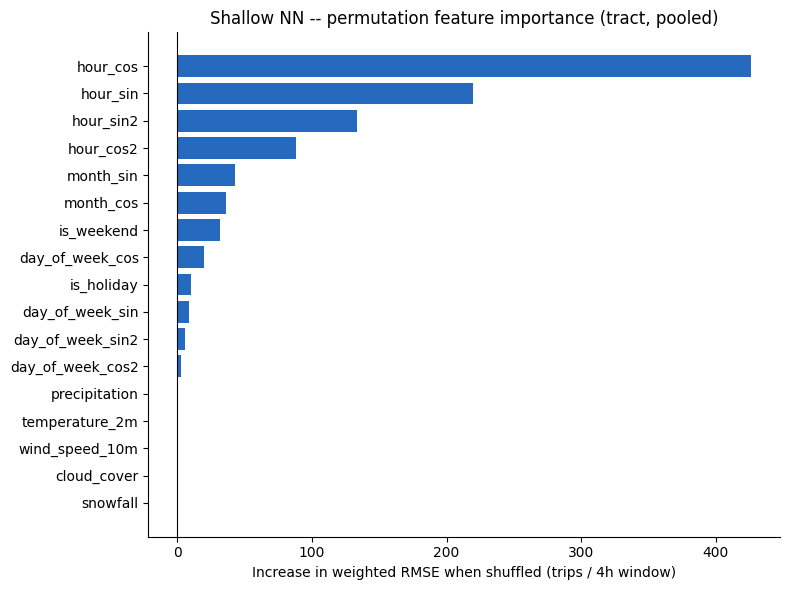

In [25]:
def permutation_importance_nn(model_wrapper, df, cols, dummy_cols, unit_weight, unit_col, n=17, n_repeats=3, seed=SEED):
    rng = np.random.default_rng(seed)
    base_pred = predict_counts(model_wrapper, df[cols])
    unit_w = df[unit_col].map(unit_weight).fillna(unit_weight.mean()).to_numpy()
    base_score = weighted_rmse(df["count"].to_numpy(dtype=float), base_pred, unit_w)

    rows = []
    for col in cols:
        if col in dummy_cols:
            continue
        deltas = []
        for _ in range(n_repeats):
            df_shuf = df.copy()
            df_shuf[col] = rng.permutation(df_shuf[col].to_numpy())
            pred = predict_counts(model_wrapper, df_shuf[cols])
            deltas.append(weighted_rmse(df_shuf["count"].to_numpy(dtype=float), pred, unit_w) - base_score)
        rows.append({"feature": col, "importance": float(np.mean(deltas))})

    return pd.DataFrame(rows).sort_values("importance", ascending=False).head(n)


# nn_fit_t-only model on nn_es_t -> out-of-sample importances.
top_imp_tract = permutation_importance_nn(
    shallow_wrapper_t_es, nn_es_t, ALL_COLS_TRACT, TRACT_DUMMY_COLS, TRACT_UNIT_WEIGHT, "tract_id",
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_imp_tract["feature"][::-1], top_imp_tract["importance"][::-1], color=SEQUENTIAL_BLUE)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel(f"Increase in weighted RMSE when shuffled (trips / {FREQ} window)")
ax.set_title("Shallow NN -- permutation feature importance (tract, pooled)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.6 Deep Neural Network -- Reusing `03.04`'s Tuned Architecture

No repeated architecture search at tract level -- the winning configuration from `03.04`'s tuning
is loaded from `results/best_deep_config.json` (falling back to `03.04`'s known winner if the
file is absent); only the training PROCEDURE is applied here (day-blocked split, weighted-RMSE
stopping, full-train refit). The architecture itself was tuned on the 77-area panel, not
re-searched for the 179-tract one (Section 7 caveat); the stopping epoch is re-found on the tract
data.

In [26]:
# Winning configuration from 03.04 Section 6 (largest, least-regularized candidate: 512/256
# hidden units, no dropout, no weight decay) -- see that notebook's deep_search_df for the full
# ranked candidate table. Only the training PROCEDURE is corrected here (day-blocked split,
# weighted-RMSE stopping, full-train refit); this architecture itself was tuned on the 77-area
# panel, not re-searched for the 179-tract one (Section 7 caveat).
# Load the config 03.04 selected + exported; fall back to its known winner (largest,
# least-regularized deep2) if the file is not present. Only the ARCHITECTURE is reused; the
# stopping epoch is re-found on the tract data by this notebook's own early-stopping phase.
_CONFIG_PATH = pathlib.Path("../../results/best_deep_config.json")
_DEFAULT_DEEP_CONFIG = {"arch": "deep2", "hidden_dim1": 512, "hidden_dim2": 256, "dropout": 0.0, "weight_decay": 0.0, "lr": 1e-3, "batch_size": 512}
if _CONFIG_PATH.exists():
    BEST_DEEP_CONFIG = json.loads(_CONFIG_PATH.read_text())
    print(f"Loaded tuned deep config from {_CONFIG_PATH} (selected in {BEST_DEEP_CONFIG.get('source_notebook', '03.04')})")
else:
    BEST_DEEP_CONFIG = _DEFAULT_DEEP_CONFIG
    print(f"{_CONFIG_PATH} not found -- falling back to 03.04's known winner: {_DEFAULT_DEEP_CONFIG}")

t0 = time.time()

# --- ES phase: find best_epoch on the day-blocked nn_es_t slice ---
prep_deep_t_es = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS_TRACT),
    ("tract_dummies", "passthrough", TRACT_DUMMY_COLS),
])
X_fit_td, y_fit_td = make_xy(nn_fit_t, ALL_COLS_TRACT, prep_deep_t_es, fit=True)
X_es_td,  y_es_td  = make_xy(nn_es_t,  ALL_COLS_TRACT, prep_deep_t_es, fit=False)

def build_deep_ctor_tract(cfg):
    if cfg.get("arch", "deep2") == "deep2":
        return lambda: DeepNet(len(ALL_COLS_TRACT), hidden_dim1=cfg["hidden_dim1"],
                               hidden_dim2=cfg["hidden_dim2"], dropout=cfg.get("dropout", 0.0))
    return lambda: DeepNet5(len(ALL_COLS_TRACT), hidden_dims=tuple(cfg["hidden_dims"]), dropout=cfg.get("dropout", 0.0))

deep_ctor_t = build_deep_ctor_tract(BEST_DEEP_CONFIG)
deep_model_t_es, deep_best_epoch_t, deep_es_loss_t = fit_with_early_stopping(
    deep_ctor_t, X_fit_td, y_fit_td, X_es_td, y_es_td,
    lr=BEST_DEEP_CONFIG["lr"], weight_decay=BEST_DEEP_CONFIG["weight_decay"],
    batch_size=BEST_DEEP_CONFIG.get("batch_size", 512),
    nn_es_df=nn_es_t, preprocess_obj=prep_deep_t_es, unit_weights=es_unit_w_t, es_true_counts=es_true_t,
    label="Deep NN (tract, 03.04 config, ES phase)",
)

# --- Final model: refit from scratch on ALL of train_tract for best_epoch epochs ---
prep_deep_t = ColumnTransformer([
    ("scale", StandardScaler(), FEATURE_COLS_TRACT),
    ("tract_dummies", "passthrough", TRACT_DUMMY_COLS),
])
X_train_td, y_train_td = make_xy(train_tract, ALL_COLS_TRACT, prep_deep_t, fit=True)
deep_model_t = fit_fixed_epochs(
    deep_ctor_t, X_train_td, y_train_td, lr=BEST_DEEP_CONFIG["lr"], weight_decay=BEST_DEEP_CONFIG["weight_decay"],
    batch_size=BEST_DEEP_CONFIG.get("batch_size", 512),
    n_epochs=deep_best_epoch_t, label="Deep NN (tract, full-train refit)",
)
deep_wrapper_t = TorchRegressor(deep_model_t, prep_deep_t)

y_pred_deep_tract = predict_counts(deep_wrapper_t, test_tract[ALL_COLS_TRACT])
pm_deep_tract = metrics(y_true_tract, y_pred_deep_tract)
res_deep_tract = per_area_results(test_tract, y_pred_deep_tract, group_col="tract_id")
res_deep_tract["skill"] = skill_vs_baseline(res_deep_tract, baseline_df=baseline_results_tract, group_col="tract_id")
fit_time_deep_tract = time.time() - t0

print_pooled_results(
    f"Deep NN, tract level ({fit_time_deep_tract:.0f}s)", pm_deep_tract, res_deep_tract,
    baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id",
    weighted_rmse_value=weighted_rmse(y_true_tract, y_pred_deep_tract, TEST_TRACT_UNIT_WEIGHTS),
)

Loaded tuned deep config from ..\..\results\best_deep_config.json (selected in 03.04_prediction_nn_CA_4h.ipynb)
Deep NN (tract, 03.04 config, ES phase): stopped after 16 epochs (best epoch 8, early-stop wRMSE 149.1519)
Deep NN (tract, full-train refit): refit on full train_tract for 8 epochs
Deep NN, tract level (366s)
  Pooled       : R2=0.821  MAE=6.18  RMSE=28.46  (sanity check only)
  Weighted RMSE: 138.71  (headline)
  Skill        : demand-weighted (headline)=-0.340  unweighted median=+0.000  median R2=0.000  (areas with negative skill: 63 of 179)


### 5.7 Results -- Tract-Level Comparison

Three candidates: profile baseline, Shallow NN, and Deep NN (reused config). See 5.7.0b for
bootstrap confidence intervals on whether Shallow and Deep actually differ.

Two headline metrics: demand-weighted skill and weighted RMSE.
                   Model  Demand-weighted skill  Median skill  Weighted RMSE  Pooled R2  Median R2/tract
Profile baseline (tract)                  0.000         0.000        100.986      0.896            0.195
              Shallow NN                 -0.098        -0.165        113.773      0.868            0.000
  Deep NN (03.04 config)                 -0.340         0.000        138.712      0.821            0.000


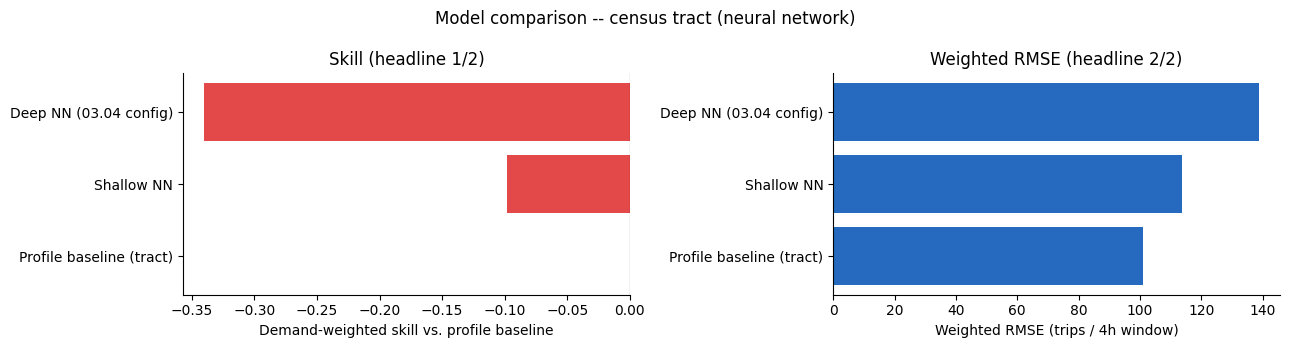

In [27]:
comparison_df_tract = pd.DataFrame([
    {"Model": "Profile baseline (tract)", "Demand-weighted skill": 0.000, "Median skill": 0.000,
     "Weighted RMSE": weighted_rmse(y_true_tract, baseline_y_pred_tract, TEST_TRACT_UNIT_WEIGHTS),
     "Pooled R2": pm_baseline_tract["r2"], "Median R2/tract": baseline_results_tract["r2"].median()},
    {"Model": "Shallow NN",
     "Demand-weighted skill": weighted_skill_vs_baseline(
         res_shallow_tract, baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     "Median skill": res_shallow_tract["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true_tract, y_pred_shallow_tract, TEST_TRACT_UNIT_WEIGHTS),
     "Pooled R2": pm_shallow_tract["r2"], "Median R2/tract": res_shallow_tract["r2"].median()},
    {"Model": "Deep NN (03.04 config)",
     "Demand-weighted skill": weighted_skill_vs_baseline(
         res_deep_tract, baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     "Median skill": res_deep_tract["skill"].median(),
     "Weighted RMSE": weighted_rmse(y_true_tract, y_pred_deep_tract, TEST_TRACT_UNIT_WEIGHTS),
     "Pooled R2": pm_deep_tract["r2"], "Median R2/tract": res_deep_tract["r2"].median()},
]).round(3)
print("Two headline metrics: demand-weighted skill and weighted RMSE.")
print(comparison_df_tract.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
chart_df_t = comparison_df_tract.set_index("Model")["Demand-weighted skill"]
colors_cmp_t = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in chart_df_t]
axes[0].barh(chart_df_t.index, chart_df_t.to_numpy(), color=colors_cmp_t)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_xlabel("Demand-weighted skill vs. profile baseline")
axes[0].set_title("Skill (headline 1/2)")
axes[0].spines[["top", "right"]].set_visible(False)

wrmse_df_t = comparison_df_tract.set_index("Model")["Weighted RMSE"]
axes[1].barh(wrmse_df_t.index, wrmse_df_t.to_numpy(), color=SEQUENTIAL_BLUE)
axes[1].set_xlabel("Weighted RMSE (trips / 4h window)")
axes[1].set_title("Weighted RMSE (headline 2/2)")
axes[1].spines[["top", "right"]].set_visible(False)
plt.suptitle("Model comparison -- census tract (neural network)")
plt.tight_layout()
plt.show()

### 5.7.0b Are the Differences Real? Day-Block Bootstrap

Resample the test period by whole days with replacement (`N_BOOT` times), recompute
demand-weighted skill vs. the tract profile baseline each time, and report a 95% CI for Shallow
NN, Deep NN, and their paired difference -- so the "NN entry carried forward" decision in 5.7.1
isn't based on a point estimate that could be noise.

Shallow NN   demand-weighted skill: -0.098  95% CI [-0.137, -0.060]
Deep NN      demand-weighted skill: -0.339  95% CI [-0.408, -0.272]

Deep - Shallow: -0.242  95% CI [-0.311, -0.174]  (P(Deep>Shallow)=0.00)
CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.


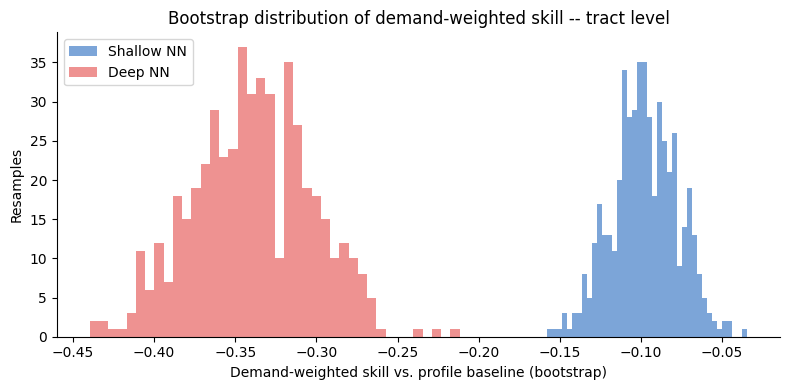

In [28]:
# Day-block bootstrap of demand-weighted skill, tract level. Resamples whole test days
# (preserving the within-day cross-tract correlation) and recomputes the headline metric each time.
test_day_t  = test_tract["timestamp"].dt.normalize().to_numpy()
uniq_days_t = np.unique(test_day_t)
tract_arr   = test_tract["tract_id"].to_numpy()
count_arr_t = test_tract["count"].to_numpy(dtype=float)
day_to_rows_t = {d: np.where(test_day_t == d)[0] for d in uniq_days_t}


def _weighted_skill_on_idx_t(idx, y_pred):
    a  = tract_arr[idx]
    em = np.abs(count_arr_t[idx] - np.asarray(y_pred)[idx])
    eb = np.abs(count_arr_t[idx] - baseline_y_pred_tract[idx])
    g  = pd.DataFrame({"a": a, "em": em, "eb": eb}).groupby("a").mean()
    g  = g[g["eb"] > 0]                       # skip tracts with a degenerate (zero-MAE) baseline
    skill = 1 - g["em"] / g["eb"]
    w = TRACT_MEDIAN_DEMAND.reindex(g.index).to_numpy()
    return float(np.average(skill.to_numpy(), weights=w)) if w.sum() > 0 else np.nan


def block_bootstrap_t(y_pred, n_boot=N_BOOT, seed=SEED):
    rng = np.random.default_rng(seed)
    out = np.empty(n_boot)
    for b in range(n_boot):
        days = rng.choice(uniq_days_t, size=len(uniq_days_t), replace=True)
        idx = np.concatenate([day_to_rows_t[d] for d in days])
        out[b] = _weighted_skill_on_idx_t(idx, y_pred)
    return out


boot_shallow_t = block_bootstrap_t(y_pred_shallow_tract)
boot_deep_t    = block_bootstrap_t(y_pred_deep_tract)
diff_t = boot_deep_t - boot_shallow_t


def _ci(a):
    a = a[~np.isnan(a)]
    return float(np.mean(a)), float(np.percentile(a, 2.5)), float(np.percentile(a, 97.5))


for name, b in [("Shallow NN", boot_shallow_t), ("Deep NN", boot_deep_t)]:
    m, lo, hi = _ci(b)
    print(f"{name:12s} demand-weighted skill: {m:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]")
dm, dlo, dhi = _ci(diff_t)
p_better_t = float(np.mean(diff_t[~np.isnan(diff_t)] > 0))
print(f"\nDeep - Shallow: {dm:+.3f}  95% CI [{dlo:+.3f}, {dhi:+.3f}]  (P(Deep>Shallow)={p_better_t:.2f})")
print("CI for the difference straddling 0 => the two NNs are statistically indistinguishable here.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(boot_shallow_t, bins=40, alpha=0.6, color=SEQUENTIAL_BLUE, label="Shallow NN")
ax.hist(boot_deep_t,    bins=40, alpha=0.6, color="#e34948",       label="Deep NN")
ax.set_xlabel("Demand-weighted skill vs. profile baseline (bootstrap)")
ax.set_ylabel("Resamples")
ax.set_title("Bootstrap distribution of demand-weighted skill -- tract level")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### 5.7.0 Actual vs. Predicted (Test Set)

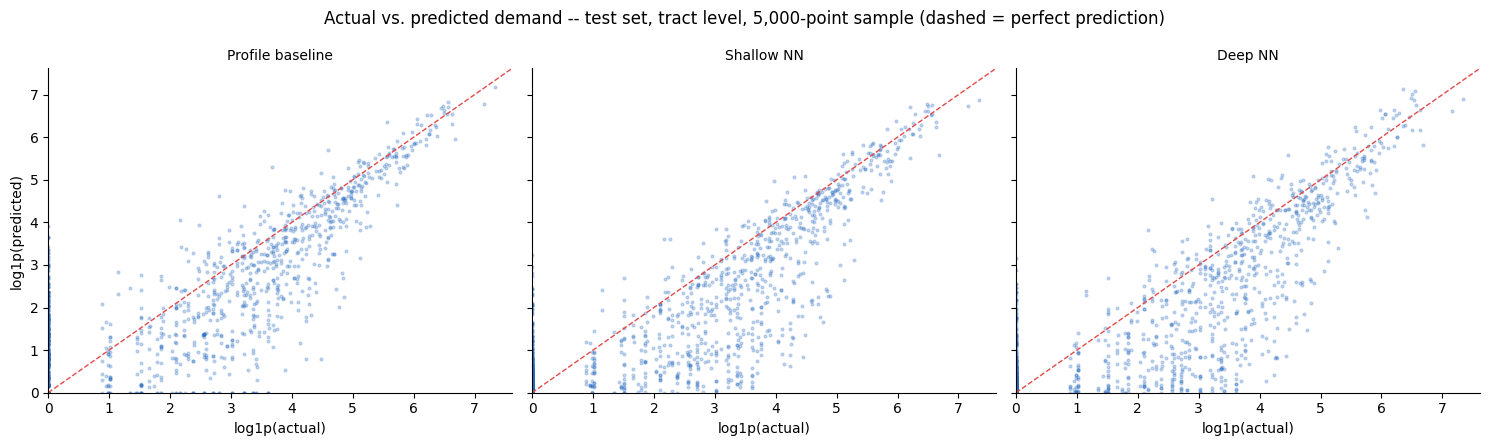

In [29]:
models_to_plot_tract = [
    ("Profile baseline", baseline_y_pred_tract),
    ("Shallow NN", y_pred_shallow_tract),
    ("Deep NN", y_pred_deep_tract),
]

rng_viz_t = np.random.RandomState(0)
sample_n_t = min(5000, len(y_true_tract))
sample_idx_t = rng_viz_t.choice(len(y_true_tract), size=sample_n_t, replace=False)
log_true_t = np.log1p(y_true_tract)
lims_t = [0, log_true_t.max()]

fig, axes = plt.subplots(1, len(models_to_plot_tract), figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (name, y_pred) in zip(axes, models_to_plot_tract):
    log_pred = np.log1p(y_pred)
    ax.scatter(log_true_t[sample_idx_t], log_pred[sample_idx_t], s=4, alpha=0.25, color=SEQUENTIAL_BLUE)
    ax.plot(lims_t, lims_t, color="#e34948", linewidth=1, linestyle="--")
    ax.set_xlim(lims_t)
    ax.set_ylim(lims_t)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("log1p(actual)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("log1p(predicted)")
plt.suptitle(f"Actual vs. predicted demand -- test set, tract level, {sample_n_t:,}-point sample "
             f"(dashed = perfect prediction)")
plt.tight_layout()
plt.show()

### 5.7.1 Per-Tract Performance

Two complementary views for whichever of Shallow/Deep NN scores higher on demand-weighted skill:
a sorted skill chart (179 tracts, x-tick labels omitted) and skill vs. tract demand, plus the
skill map.

NN entry carried forward for the per-tract breakdown: Shallow NN


c:\Uni Koeln\AAA_Project\AAA_Team_1\.venv\Lib\site-packages\matplotlib\transforms.py:2437: RuntimeWarning: invalid value encountered in dot
  return Affine2D(np.dot(self._b.get_affine().get_matrix(),


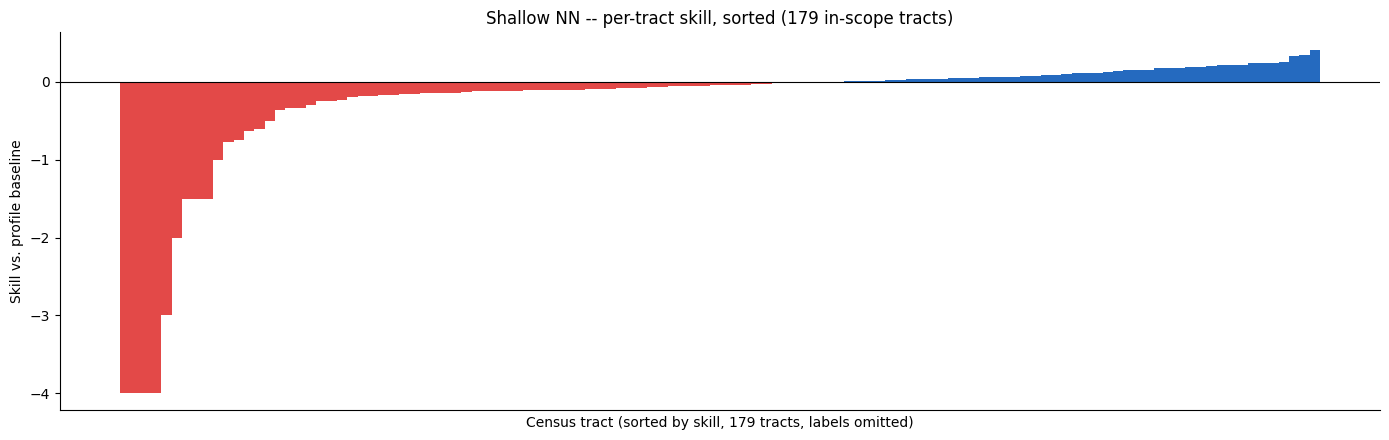

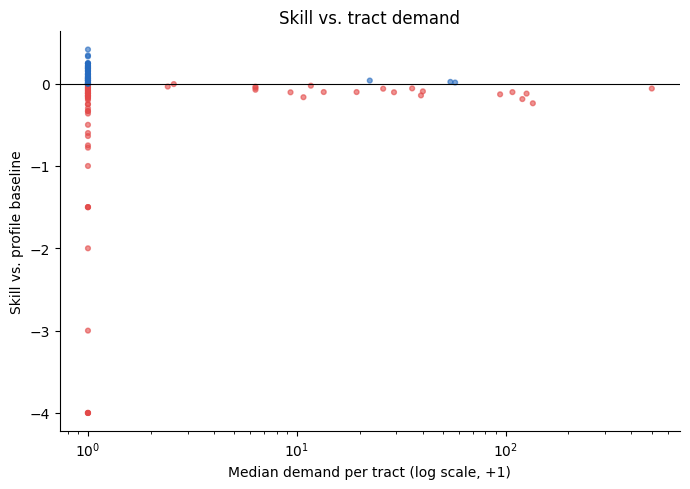

In [30]:
nn_entry_name_t = "Deep NN" if weighted_skill_vs_baseline(
    res_deep_tract, baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id",
) >= weighted_skill_vs_baseline(
    res_shallow_tract, baseline_df=baseline_results_tract, median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id",
) else "Shallow NN"
res_nn_tract = res_deep_tract if nn_entry_name_t == "Deep NN" else res_shallow_tract
print(f"NN entry carried forward for the per-tract breakdown: {nn_entry_name_t}")

res_nn_tract_by_skill = res_nn_tract.sort_values("skill").reset_index(drop=True)
colors_skill_t = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_nn_tract_by_skill["skill"]]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.bar(range(len(res_nn_tract_by_skill)), res_nn_tract_by_skill["skill"], color=colors_skill_t, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks([])
ax.set_xlabel(f"Census tract (sorted by skill, {len(res_nn_tract_by_skill)} tracts, labels omitted)")
ax.set_ylabel("Skill vs. profile baseline")
ax.set_title(f"{nn_entry_name_t} -- per-tract skill, sorted (179 in-scope tracts)")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

res_nn_tract_ranked = res_nn_tract.merge(TRACT_MEDIAN_DEMAND, left_on="tract_id", right_index=True)
colors_tract = [SEQUENTIAL_BLUE if v >= 0 else "#e34948" for v in res_nn_tract_ranked["skill"]]

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(res_nn_tract_ranked["median_demand"] + 1, res_nn_tract_ranked["skill"], color=colors_tract, s=12, alpha=0.6)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel("Median demand per tract (log scale, +1)")
ax.set_ylabel("Skill vs. profile baseline")
ax.set_title("Skill vs. tract demand")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Per-tract skill map for the NN entry, at the 179 in-scope tracts.

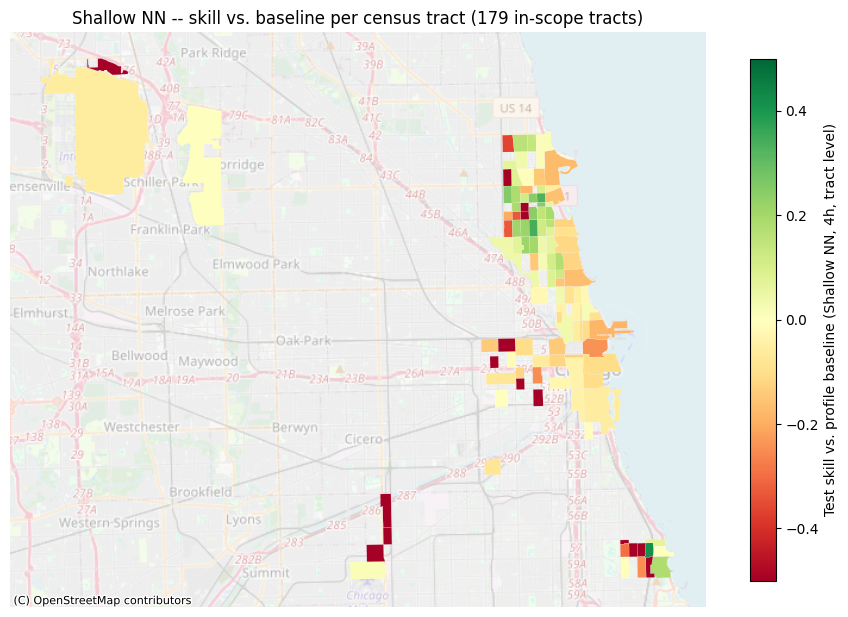

In [31]:
gdf_skill_tract = tracts_gdf[["tract_id", "geometry"]].merge(
    res_nn_tract[["tract_id", "skill"]], on="tract_id", how="left",
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
gdf_skill_tract.plot(ax=ax, column="skill", cmap="RdYlGn", vmin=-0.5, vmax=0.5, legend=True,
                     legend_kwds={"label": f"Test skill vs. profile baseline ({nn_entry_name_t}, 4h, tract level)", "shrink": 0.6},
                     edgecolor="white", linewidth=0.1)
ctx.add_basemap(ax, crs=gdf_skill_tract.crs, source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
ax.set_title(f"{nn_entry_name_t} -- skill vs. baseline per census tract (179 in-scope tracts)")
ax.axis("off")
plt.tight_layout()
plt.show()

### 5.7.2 Top 3 Tracts -- All Models

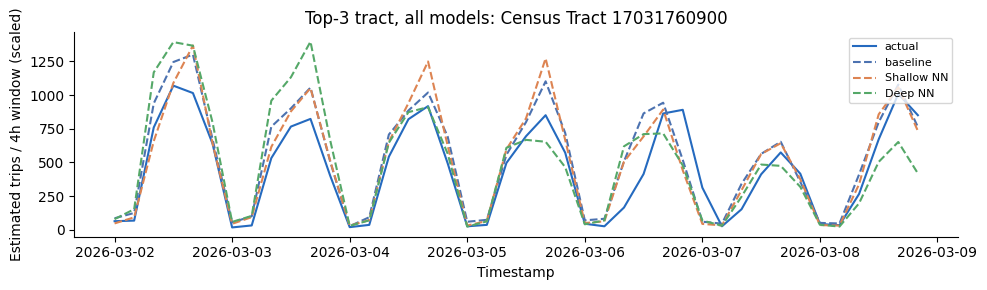

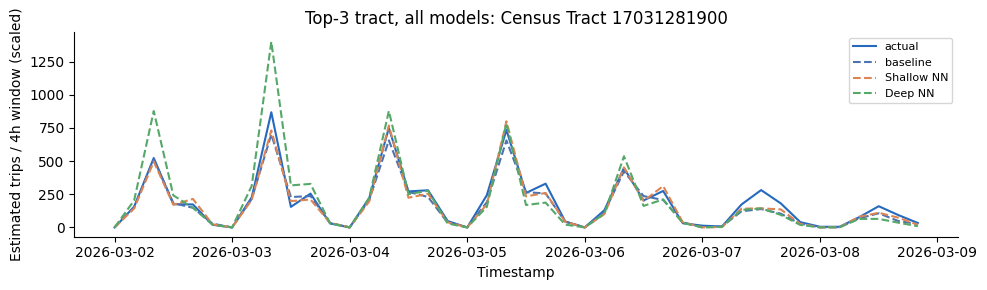

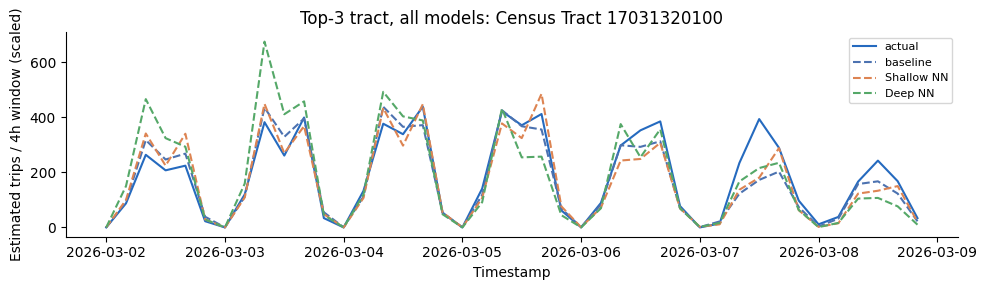

In [32]:
test_plot_pred_shallow_t = y_pred_shallow_tract[eval_mask_t.to_numpy()]
test_plot_pred_deep_t    = y_pred_deep_tract[eval_mask_t.to_numpy()]

TRACT_MODEL_COLORS = ["#4C72B0", "#DD8452", "#55A868"]

for tract in top_3_tracts:
    mask = (test_plot_t["tract_id"] == tract).to_numpy()
    area_val = test_plot_t[mask]

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(area_val["timestamp"], area_val["count"], label="actual", color=SEQUENTIAL_BLUE)
    ax.plot(area_val["timestamp"], test_plot_pred_base_t[mask], label="baseline", color=TRACT_MODEL_COLORS[0], linestyle="--")
    ax.plot(area_val["timestamp"], test_plot_pred_shallow_t[mask], label="Shallow NN", color=TRACT_MODEL_COLORS[1], linestyle="--")
    ax.plot(area_val["timestamp"], test_plot_pred_deep_t[mask], label="Deep NN", color=TRACT_MODEL_COLORS[2], linestyle="--")
    ax.set_title(f"Top-3 tract, all models: Census Tract {tract}")
    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Estimated trips / 4h window (scaled)")
    ax.legend(loc="upper right", fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

## 6. Export Results

Append this run's three models (profile baseline, Shallow NN, Deep NN) to the shared
`model_results_summary.csv` and `model_results_by_area.csv`, distinguished by
`spatial_resolution="census_tract"`.

In [33]:
RESULTS_DIR = pathlib.Path("../../results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SUMMARY_CSV = RESULTS_DIR / "model_results_summary.csv"
DETAIL_CSV  = RESULTS_DIR / "model_results_by_area.csv"
NOTEBOOK_NAME = "03.06_prediction_nn_tract.ipynb"


def upsert_csv(df_new, path, key_cols):
    if path.exists():
        df_old = pd.read_csv(path)
        old_keys = df_old[key_cols].apply(tuple, axis=1)
        new_keys = set(df_new[key_cols].apply(tuple, axis=1))
        df_out = pd.concat([df_old[~old_keys.isin(new_keys)], df_new], ignore_index=True)
    else:
        df_out = df_new
    df_out.to_csv(path, index=False)
    return df_out


run_timestamp = pd.Timestamp.now().isoformat(timespec="seconds")

tract_models = [
    ("Profile baseline (tract)", pm_baseline_tract, baseline_results_tract,
     weighted_rmse(y_true_tract, baseline_y_pred_tract, TEST_TRACT_UNIT_WEIGHTS), 0.0, 0.0, None),
    ("Shallow NN", pm_shallow_tract, res_shallow_tract,
     weighted_rmse(y_true_tract, y_pred_shallow_tract, TEST_TRACT_UNIT_WEIGHTS),
     weighted_skill_vs_baseline(res_shallow_tract, baseline_df=baseline_results_tract,
                                 median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     res_shallow_tract["skill"].median(), fit_time_shallow_tract),
    ("Deep NN (03.04 config)", pm_deep_tract, res_deep_tract,
     weighted_rmse(y_true_tract, y_pred_deep_tract, TEST_TRACT_UNIT_WEIGHTS),
     weighted_skill_vs_baseline(res_deep_tract, baseline_df=baseline_results_tract,
                                 median_demand=TRACT_MEDIAN_DEMAND, group_col="tract_id"),
     res_deep_tract["skill"].median(), fit_time_deep_tract),
]

summary_rows, detail_rows = [], []
for model_name, pm, res_df, wrmse, skill_w, skill_med, fit_time in tract_models:
    summary_rows.append({
        "model_name": model_name,
        "notebook": NOTEBOOK_NAME,
        "spatial_resolution": "census_tract",
        "temporal_resolution": FREQ,
        "n_units": len(ALL_TRACTS),
        "train_start": DATA_START.date().isoformat(),
        "train_end": (TRAIN_END - pd.Timedelta(days=1)).date().isoformat(),
        "test_start": TRAIN_END.date().isoformat(),
        "test_end": (DATA_END_EXCL - pd.Timedelta(days=1)).date().isoformat(),
        "rmse": pm["rmse"],
        "mae": pm["mae"],
        "r2": pm["r2"],
        "weighted_rmse": wrmse,
        "skill_demand_weighted": round(float(skill_w), 4),
        "skill_median": round(float(skill_med), 4),
        "fit_time_s": round(fit_time, 2) if fit_time is not None else None,
        "last_run_at": run_timestamp,
    })
    for _, row in res_df.iterrows():
        detail_rows.append({
            "model_name": model_name,
            "notebook": NOTEBOOK_NAME,
            "spatial_resolution": "census_tract",
            "temporal_resolution": FREQ,
            "unit_id": int(row["tract_id"]),
            "median_demand": TRACT_MEDIAN_DEMAND.get(row["tract_id"]),
            "rmse": row["rmse"],
            "mae": row["mae"],
            "r2": row["r2"],
            "skill": row.get("skill", 0.0),
            "relative_mae": None,
            "last_run_at": run_timestamp,
        })

summary_df = pd.DataFrame(summary_rows)
detail_df = pd.DataFrame(detail_rows)

upsert_csv(summary_df, SUMMARY_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution"])
upsert_csv(detail_df, DETAIL_CSV,
           key_cols=["model_name", "notebook", "spatial_resolution", "temporal_resolution", "unit_id"])

print(f"Wrote {len(summary_df)} rows to {SUMMARY_CSV}")
print(f"Wrote {len(detail_df)} rows to {DETAIL_CSV}")
summary_df

Wrote 3 rows to ..\..\results\model_results_summary.csv
Wrote 537 rows to ..\..\results\model_results_by_area.csv


,model_name,notebook,spatial_resolution,temporal_resolution,n_units,train_start,train_end,test_start,test_end,rmse,mae,r2,weighted_rmse,skill_demand_weighted,skill_median,fit_time_s,last_run_at
0,Profile baseline (tract),03.06_prediction_nn_tract.ipynb,census_tract,4h,179,2024-01-01,2025-12-31,2026-01-01,2026-05-31,21.64,5.22,0.8965,100.985601,0.0000,0.0000,NaN,2026-07-24T13:47:05
1,Shallow NN,03.06_prediction_nn_tract.ipynb,census_tract,4h,179,2024-01-01,2025-12-31,2026-01-01,2026-05-31,24.43,5.60,0.8680,113.772690,-0.0977,-0.1649,529.27,2026-07-24T13:47:05
2,Deep NN (03.04 config),03.06_prediction_nn_tract.ipynb,census_tract,4h,179,2024-01-01,2025-12-31,2026-01-01,2026-05-31,28.46,6.18,0.8209,138.711680,-0.3396,0.0000,365.68,2026-07-24T13:47:05


## 7. Shortfalls & Honest Limitations

- **Scope cut to 11 of 77 community areas** (5.0): a data-availability ceiling, not a modeling
  choice. `03.05` is the fallback for the other 66 areas.
- **Scaled counts are estimates, not observations** (5.2): the `1/retention_frac` correction
  assumes tract-precision trips are representative within each included area.
- **One-hot tract dummies memorize identity, they don't generalize** (5.1): a `tract_id` dummy
  carries no information transferable to a tract outside the 179 in scope -- if the modeling
  scope ever grows, the whole dummy block needs rebuilding and retraining rather than just
  scoring new rows through the existing model. Not a live problem today, but it's the trade-off
  for the accuracy gain this switch produces: the earlier covariate-based representation
  generalized in principle but scored below the profile baseline (5.1), the more consequential
  failure at this stage.
- **No repeated architecture search** (5.6): the Deep NN reuses `03.04`'s winning
  hyperparameters rather than re-tuning at tract scale. A config tuned for the ~93-column
  community-area panel isn't guaranteed to be the best choice for the ~195-column tract panel
  (17 features + 178 tract dummies); only the *training procedure* was corrected here, not
  whether 512/256/no-dropout is still the right architecture for this much wider input.
- **`best_epoch` is an approximation on refit**, same caveat as `03.04`: one epoch on full
  `train_tract` covers ~25% more gradient steps than during the ES phase, so the reused epoch
  count is a heuristic, not an exact transfer.

## 8. Outlook

- Results feed the NN section of the report, alongside `03.04` and `03.05`, via the shared
  `results/model_results_summary.csv`.
- The 66 excluded community areas remain covered only at `03.05`'s resolution -- not fixable
  without richer location data than the portal provides.